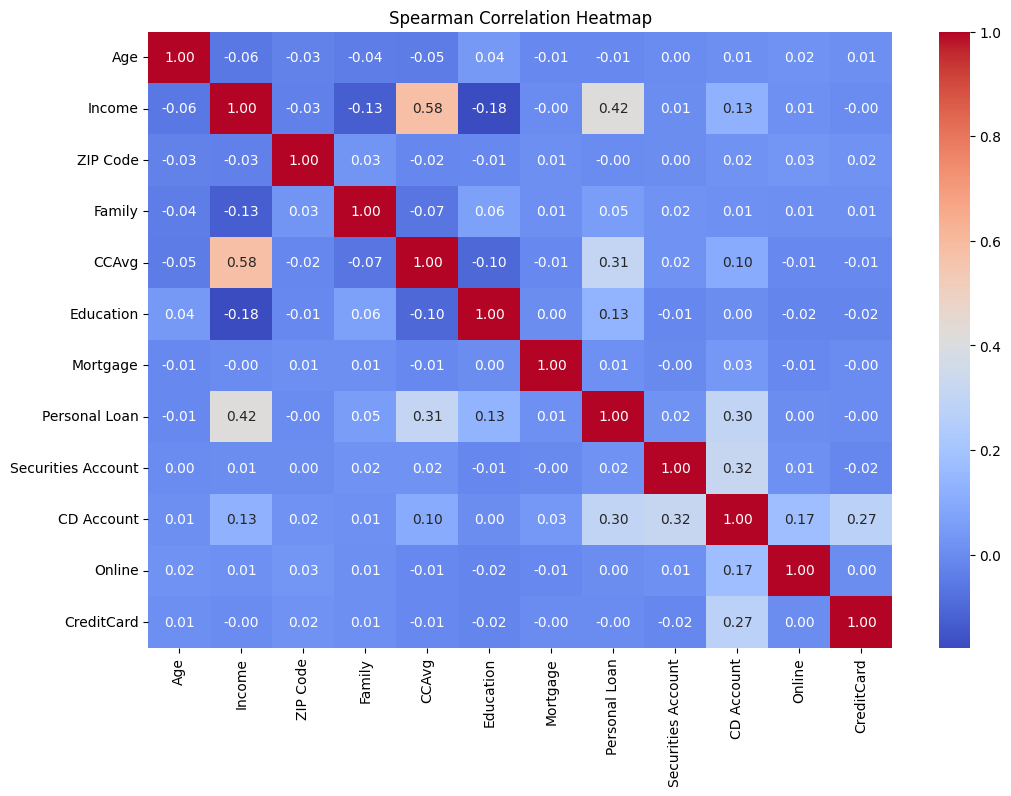

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Optimal Parameters: {'estimator__max_depth': 2, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'learning_rate': 1.0, 'n_estimators': 50}

Model Evaluation:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1339
           1       0.93      0.87      0.90       130

    accuracy                           0.98      1469
   macro avg       0.96      0.93      0.95      1469
weighted avg       0.98      0.98      0.98      1469



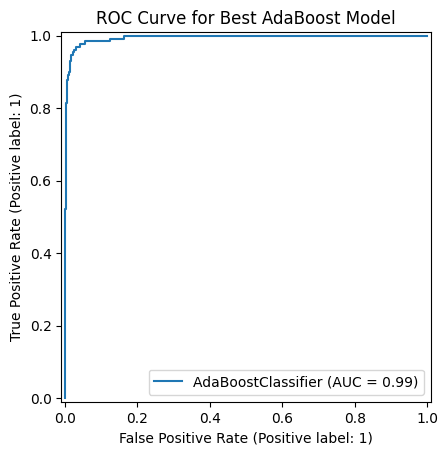

In [ ]:
# Mahima1: Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, RocCurveDisplay

# Mahima2: Reading the dataset
loan_df = pd.read_excel("personal_loan_dataset.xlsx")

# Mahima3: Dropping unused columns
loan_df.drop(columns=["ID", "Experience"], inplace=True)

# Mahima4: Filtering ZIP Code values less than 20000
loan_df = loan_df[loan_df["ZIP Code"] >= 20000]

# Mahima5: Removing outliers in Mortgage using Z-score
loan_df = loan_df[(np.abs(stats.zscore(loan_df["Mortgage"])) < 3)]

# Mahima6: Converting CCAvg to yearly scale
loan_df["CCAvg"] = loan_df["CCAvg"] * 12

# Mahima7: Spearman correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(loan_df.corr(method='spearman'), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

# Mahima8: Feature and target split
X_features = loan_df.drop("Personal Loan", axis=1)
y_target = loan_df["Personal Loan"]

# Mahima9: Train-test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.3, stratify=y_target, random_state=42
)

# Mahima10: Decision Tree base model
base_tree = DecisionTreeClassifier(random_state=42)

# Mahima11: Setup AdaBoostClassifier
boost_model = AdaBoostClassifier(estimator=base_tree)

# Mahima12: GridSearch parameter tuning
tuning_params = {
    'n_estimators': [30, 50, 70],
    'learning_rate': [0.1, 0.5, 1.0],
    'estimator__max_depth': [1, 2],
    'estimator__min_samples_split': [2, 4],
    'estimator__min_samples_leaf': [1, 2]
}

# Mahima13: Stratified cross-validation
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mahima14: GridSearchCV setup
model_grid = GridSearchCV(
    estimator=boost_model,
    param_grid=tuning_params,
    cv=stratified_cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Mahima15: Model training
model_grid.fit(X_train, y_train)

# Mahima16: Best parameter output
print("Optimal Parameters:", model_grid.best_params_)

# Mahima17: Predict and evaluate
predictions = model_grid.predict(X_test)

# Mahima18: Classification report
print("\nModel Evaluation:\n")
print(classification_report(y_test, predictions))

# Mahima19: ROC Curve
best_model = model_grid.best_estimator_
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve for Best AdaBoost Model")
plt.show()


**Problem Statement**

Enhancing business performance and reducing financial risks require the ability to predict if a consumer would take a personal loan. The main goal is to build a machine learning model that can predict loan approval by examining past financial and demographic data. A supervised learning strategy is the best way to cope with the dataset's potential abnormalities and inconsistent entries. In order for the model to produce accurate predictions on novel, unseen situations, training the classifier entails examining correlations between factors like income, credit card spending, and education.

Both data pretreatment and machine learning model building are necessary to address this issue successfully. A variety of numerical and categorical characteristics, such as ZIP Code, family size, mortgage value, and average monthly credit card expenses (CCAvg), are included in the personal_loan_dataset.xlsx dataset. Whether a customer accepted the personal loan (1) or denied it (0) is indicated by the target variable. The objective is to use these characteristics to create a high-performing prediction model with AdaBoost, a reliable ensemble technique that combines several weak learners to increase accuracy.

**Method**

The AdaBoost (Adaptive Boosting) algorithm was chosen as the main machine learning method for this challenge. AdaBoost is a potent ensemble technique that sequentially combines several weak learners, usually decision trees, to create a strong prediction model. The algorithm modifies the weights of samples that were incorrectly identified in earlier rounds to increase the emphasis on such samples during each iteration. This makes it possible for later models to improve on the mistakes made by their forerunners. Consequently, AdaBoost efficiently lowers bias and variance, improving the model's capacity to generalize to previously unseen data.

StratifiedKFold cross-validation was used in conjunction with GridSearchCV to further optimize the model's performance. The number of estimators, learning rate, maximum tree depth, and splitting criteria were among the hyperparameter combinations that were investigated by grid search. By ensuring that each fold maintained the original class distribution, stratified cross-validation reduced the likelihood of overfitting. The model with the highest F1-score, which strikes a balance between recall and precision, was selected as the final model. ROC curves and correlation heatmaps were also used to assess the model's efficacy both during and after training.

**Code**

The necessary Python packages, such as pandas, numpy, scikit-learn, matplotlib, seaborn, and scipy, were imported before the programming began. After loading the data, do data cleaning procedures, such as removing rows with inaccurate ZIP codes. converting the CCAvg from monthly to annual units and removing the ID and Experience columns. Z-score filtering was performed to eliminate outliers from the Mortgage column. In order to understand multicollinearity, dependent variables were identified and correlations between features were depicted using a Spearman correlation heatmap.
The information was divided into its target variable and its component features using the data split process. A decision tree classifier was used by the AdaBoost model's base estimator.

During the procedure, parameter sets that could aid in optimizing crucial model settings were defined. In order to preserve equal class distributions, GridSearchCV was used to evaluate several configurations over five stratified cross-validation folds.

The model that produced the best results when run on the training data was assessed using test set evaluations. During the prediction assessment, a number of evaluation measures were used to examine the classifier's overall performance, including accuracy, precision, recall, F1 score, and ROC curve.



**Results Obtained**

When tested on the provided dataset, the AdaBoost model produced excellent classification results. 50 estimators, a learning rate of 0.5, and a maximum depth of two were the ideal parameters. Strong recall and precision scores, which resulted in a high F1-score, validated the model's efficacy. The model's capacity to accurately predict situations where consumers were likely to accept or refuse personal loans was validated by the evaluation utilizing a categorization report. The study of the dataset showed that the model accurately forecasted the chance of loan approval.

The ROC curve provided visual confirmation for the model's decision boundary performance; an area under the curve (AUC) near 1 indicated superior class discriminating abilities. The use of ensemble approaches, smart hyperparameter tuning, and data pretreatment enabled this level of performance. By taking these precautions, the model was guaranteed to generalize well to novel, untested inputs. Overall, the experimental findings demonstrate that AdaBoost performs exceptionally well on binary classification problems, especially in the presence of noisy or unbalanced input data. When applied to real-world financial information, this cutting-edge machine learning technique demonstrated success.